In [164]:
# Enable auto-reloading of external modules
%load_ext autoreload  
%autoreload 2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [165]:
train_df = pd.read_csv("../artifacts/data/train.csv")
train_df.head()

,churn,MonthlyRevenue,TotalRecurringCharge,OverageMinutes,PercChangeRevenues,MonthlyMinutes,PercChangeMinutes,RoamingCalls,DroppedCalls,BlockedCalls,...,MonthsInService,CurrentEquipmentDays,HandsetPrice,HandsetRefurbished,HandsetWebCapable,AgeHH1,CreditRating,IncomeGroup,Occupation,ReferralsMadeBySubscriber
0,No,39.79,55.0,0.0,8.8,234.0,31.0,1.7,6.7,0.7,...,7,211.0,Unknown,No,Yes,0.0,2-High,0,Other,0
1,No,60.19,60.0,0.0,-10.2,551.0,-88.0,0.3,2.7,32.7,...,11,122.0,150,No,Yes,30.0,2-High,7,Crafts,0
2,No,85.41,28.0,134.0,22.8,642.0,129.0,0.0,29.7,0.0,...,13,393.0,Unknown,No,Yes,44.0,2-High,4,Crafts,0
3,Yes,30.18,30.0,0.0,-0.2,281.0,132.0,0.0,4.0,0.0,...,20,465.0,150,No,Yes,0.0,3-Good,3,Other,0
4,Yes,179.29,95.0,118.0,-77.0,1459.0,-1360.0,48.6,21.7,11.0,...,12,349.0,Unknown,No,Yes,42.0,3-Good,4,Other,0


In [166]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40837 entries, 0 to 40836
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      40837 non-null  object 
 1   MonthlyRevenue             40717 non-null  float64
 2   TotalRecurringCharge       40717 non-null  float64
 3   OverageMinutes             40717 non-null  float64
 4   PercChangeRevenues         40547 non-null  float64
 5   MonthlyMinutes             40717 non-null  float64
 6   PercChangeMinutes          40547 non-null  float64
 7   RoamingCalls               40717 non-null  float64
 8   DroppedCalls               40837 non-null  float64
 9   BlockedCalls               40837 non-null  float64
 10  CustomerCareCalls          40837 non-null  float64
 11  MonthsInService            40837 non-null  int64  
 12  CurrentEquipmentDays       40836 non-null  float64
 13  HandsetPrice               40837 non-null  obj

In [167]:
train_df.isna().sum()

churn                          0
MonthlyRevenue               120
TotalRecurringCharge         120
OverageMinutes               120
PercChangeRevenues           290
MonthlyMinutes               120
PercChangeMinutes            290
RoamingCalls                 120
DroppedCalls                   0
BlockedCalls                   0
CustomerCareCalls              0
MonthsInService                0
CurrentEquipmentDays           1
HandsetPrice                   0
HandsetRefurbished             0
HandsetWebCapable              0
AgeHH1                       716
CreditRating                   0
IncomeGroup                    0
Occupation                     0
ReferralsMadeBySubscriber      0
dtype: int64

In [168]:
train_df.duplicated().sum()

np.int64(0)

In [169]:
train_df.describe()

,MonthlyRevenue,TotalRecurringCharge,OverageMinutes,PercChangeRevenues,MonthlyMinutes,PercChangeMinutes,RoamingCalls,DroppedCalls,BlockedCalls,CustomerCareCalls,MonthsInService,CurrentEquipmentDays,AgeHH1,IncomeGroup,ReferralsMadeBySubscriber
count,40717.000000,40717.000000,40717.000000,40547.000000,40717.000000,40547.000000,40717.000000,40837.000000,40837.000000,40837.00000,40837.000000,40836.000000,40121.000000,40837.000000,40837.000000
mean,58.992118,46.859002,40.311344,-1.119353,525.242872,-11.750586,1.238755,6.005897,4.063070,1.86581,18.784215,380.441645,31.294908,4.326028,0.053554
std,44.953808,23.854207,97.921075,41.021682,528.398044,257.671706,10.406285,8.992924,10.888915,4.96182,9.832489,253.728942,22.113749,3.138536,0.324192
min,-6.170000,-11.000000,0.000000,-1107.700000,0.000000,-3406.000000,0.000000,0.000000,0.000000,0.00000,6.000000,-5.000000,0.000000,0.000000,0.000000
25%,33.710000,30.000000,0.000000,-7.000000,158.000000,-83.000000,0.000000,0.700000,0.000000,0.00000,11.000000,205.000000,0.000000,0.000000,0.000000
50%,48.470000,45.000000,3.000000,-0.300000,367.000000,-6.000000,0.000000,3.000000,1.000000,0.00000,16.000000,329.000000,36.000000,5.000000,0.000000
75%,71.030000,60.000000,41.000000,1.600000,724.000000,65.000000,0.200000,7.700000,3.700000,1.70000,24.000000,516.000000,48.000000,7.000000,0.000000
max,1223.380000,400.000000,4321.000000,2483.500000,7359.000000,5192.000000,1112.400000,221.700000,384.300000,327.30000,61.000000,1812.000000,99.000000,9.000000,35.000000


**checking the columns that have nulls**

<Axes: >

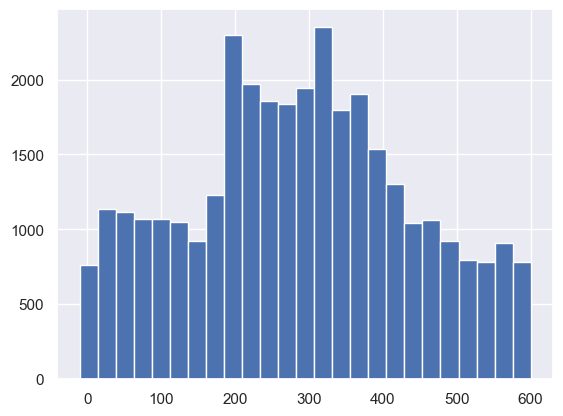

In [170]:
train_df["CurrentEquipmentDays"].hist(range=(-10, 600), bins=25)

In [171]:
train_df[["MonthlyRevenue", "TotalRecurringCharge", "OverageMinutes", "PercChangeRevenues", "RoamingCalls", "MonthlyMinutes"]].isnull().groupby(train_df["churn"]).sum()

,MonthlyRevenue,TotalRecurringCharge,OverageMinutes,PercChangeRevenues,RoamingCalls,MonthlyMinutes
churn,,,,,,
No,65,65,65,125,65,65
Yes,55,55,55,165,55,55


In [172]:
#  "Extra 170" and check their average tenure
extra_nulls_mask = (train_df['PercChangeRevenues'].isnull()) & (train_df['MonthlyRevenue'].notnull())
train_df[extra_nulls_mask]['MonthsInService'].describe()

count    170.000000
mean      23.641176
std       13.872435
min        7.000000
25%       14.000000
50%       19.000000
75%       30.000000
max       60.000000
Name: MonthsInService, dtype: float64

In [173]:
# Look at the Current Usage for people who have Null in PercChange
train_df[train_df['PercChangeMinutes'].isna()]['MonthlyMinutes'].describe()

count     170.000000
mean      326.141176
std       468.320167
min         0.000000
25%         3.500000
50%       194.000000
75%       410.750000
max      2747.000000
Name: MonthlyMinutes, dtype: float64

In [174]:
train_df.isnull().mean() * 100

churn                        0.000000
MonthlyRevenue               0.293851
TotalRecurringCharge         0.293851
OverageMinutes               0.293851
PercChangeRevenues           0.710140
MonthlyMinutes               0.293851
PercChangeMinutes            0.710140
RoamingCalls                 0.293851
DroppedCalls                 0.000000
BlockedCalls                 0.000000
CustomerCareCalls            0.000000
MonthsInService              0.000000
CurrentEquipmentDays         0.002449
HandsetPrice                 0.000000
HandsetRefurbished           0.000000
HandsetWebCapable            0.000000
AgeHH1                       1.753312
CreditRating                 0.000000
IncomeGroup                  0.000000
Occupation                   0.000000
ReferralsMadeBySubscriber    0.000000
dtype: float64

**Step 1: replacing liar zeros**

In [175]:
train_df['AgeHH1'] = train_df['AgeHH1'].replace(0, np.nan)
train_df['IncomeGroup'] = train_df['IncomeGroup'].replace(0, np.nan)


In [176]:
train_df['HandsetPrice'] = train_df['HandsetPrice'].replace("Unknown", np.nan).astype(float)

In [177]:
train_df.describe()

,MonthlyRevenue,TotalRecurringCharge,OverageMinutes,PercChangeRevenues,MonthlyMinutes,PercChangeMinutes,RoamingCalls,DroppedCalls,BlockedCalls,CustomerCareCalls,MonthsInService,CurrentEquipmentDays,HandsetPrice,AgeHH1,IncomeGroup,ReferralsMadeBySubscriber
count,40717.000000,40717.000000,40717.000000,40547.000000,40717.000000,40547.000000,40717.000000,40837.000000,40837.000000,40837.00000,40837.000000,40836.000000,17623.000000,28941.000000,30557.000000,40837.000000
mean,58.992118,46.859002,40.311344,-1.119353,525.242872,-11.750586,1.238755,6.005897,4.063070,1.86581,18.784215,380.441645,82.131306,43.384230,5.781392,0.053554
std,44.953808,23.854207,97.921075,41.021682,528.398044,257.671706,10.406285,8.992924,10.888915,4.96182,9.832489,253.728942,60.440890,12.386668,2.179470,0.324192
min,-6.170000,-11.000000,0.000000,-1107.700000,0.000000,-3406.000000,0.000000,0.000000,0.000000,0.00000,6.000000,-5.000000,10.000000,18.000000,1.000000,0.000000
25%,33.710000,30.000000,0.000000,-7.000000,158.000000,-83.000000,0.000000,0.700000,0.000000,0.00000,11.000000,205.000000,30.000000,34.000000,4.000000,0.000000
50%,48.470000,45.000000,3.000000,-0.300000,367.000000,-6.000000,0.000000,3.000000,1.000000,0.00000,16.000000,329.000000,60.000000,42.000000,6.000000,0.000000
75%,71.030000,60.000000,41.000000,1.600000,724.000000,65.000000,0.200000,7.700000,3.700000,1.70000,24.000000,516.000000,130.000000,52.000000,7.000000,0.000000
max,1223.380000,400.000000,4321.000000,2483.500000,7359.000000,5192.000000,1112.400000,221.700000,384.300000,327.30000,61.000000,1812.000000,500.000000,99.000000,9.000000,35.000000


<Axes: >

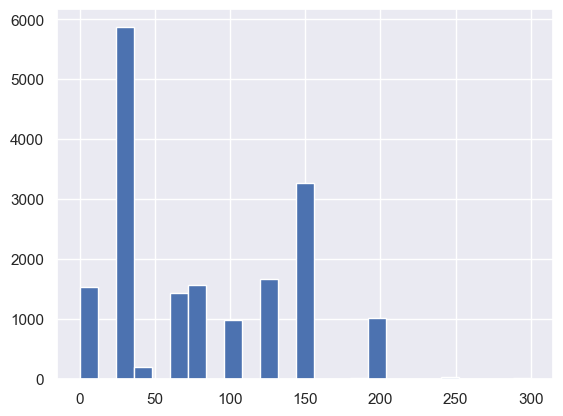

In [178]:
train_df['HandsetPrice'].hist(range=(0, 300), bins=25)

In [179]:
train_df.isna().sum()

churn                            0
MonthlyRevenue                 120
TotalRecurringCharge           120
OverageMinutes                 120
PercChangeRevenues             290
MonthlyMinutes                 120
PercChangeMinutes              290
RoamingCalls                   120
DroppedCalls                     0
BlockedCalls                     0
CustomerCareCalls                0
MonthsInService                  0
CurrentEquipmentDays             1
HandsetPrice                 23214
HandsetRefurbished               0
HandsetWebCapable                0
AgeHH1                       11896
CreditRating                     0
IncomeGroup                  10280
Occupation                       0
ReferralsMadeBySubscriber        0
dtype: int64

**Step 2: fill nulls with the median cause most columns are skewed**

we will add a missing indcator for all besides "CurrentEquipmentDays" 

In [180]:
cols = ["MonthlyRevenue", "TotalRecurringCharge", "OverageMinutes", "PercChangeRevenues", "MonthlyMinutes", "PercChangeMinutes", "RoamingCalls", 
        "AgeHH1", "IncomeGroup", "HandsetPrice", "CurrentEquipmentDays"]
train_df[cols] = train_df[cols].fillna(train_df[cols].median())

In [181]:
train_df.isna().sum()

churn                        0
MonthlyRevenue               0
TotalRecurringCharge         0
OverageMinutes               0
PercChangeRevenues           0
MonthlyMinutes               0
PercChangeMinutes            0
RoamingCalls                 0
DroppedCalls                 0
BlockedCalls                 0
CustomerCareCalls            0
MonthsInService              0
CurrentEquipmentDays         0
HandsetPrice                 0
HandsetRefurbished           0
HandsetWebCapable            0
AgeHH1                       0
CreditRating                 0
IncomeGroup                  0
Occupation                   0
ReferralsMadeBySubscriber    0
dtype: int64

In [182]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40837 entries, 0 to 40836
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      40837 non-null  object 
 1   MonthlyRevenue             40837 non-null  float64
 2   TotalRecurringCharge       40837 non-null  float64
 3   OverageMinutes             40837 non-null  float64
 4   PercChangeRevenues         40837 non-null  float64
 5   MonthlyMinutes             40837 non-null  float64
 6   PercChangeMinutes          40837 non-null  float64
 7   RoamingCalls               40837 non-null  float64
 8   DroppedCalls               40837 non-null  float64
 9   BlockedCalls               40837 non-null  float64
 10  CustomerCareCalls          40837 non-null  float64
 11  MonthsInService            40837 non-null  int64  
 12  CurrentEquipmentDays       40837 non-null  float64
 13  HandsetPrice               40837 non-null  flo

**Step 3: Handling Oultiers**

In [183]:
stats = train_df.describe(percentiles=[.01, .50, .75, .90, .95, .99]).T
stats.assign(diff=stats["max"] - stats["99%"]).sort_values(by="diff", ascending=False)

,count,mean,std,min,1%,50%,75%,90%,95%,99%,max,diff
MonthlyMinutes,40837.0,524.777873,527.690625,0.00,0.000,367.00,722.00,1194.00,1568.20,2448.2000,7359.00,4910.8000
PercChangeMinutes,40837.0,-11.709749,256.755592,-3406.00,-845.280,-6.00,64.00,206.00,344.00,740.6400,5192.00,4451.3600
OverageMinutes,40837.0,40.201704,97.797950,0.00,0.000,3.00,40.00,116.00,190.00,433.6400,4321.00,3887.3600
PercChangeRevenues,40837.0,-1.113534,40.875821,-1107.70,-105.864,-0.30,1.60,21.70,46.50,117.1560,2483.50,2366.3440
RoamingCalls,40837.0,1.235115,10.391201,0.00,0.000,0.00,0.20,2.10,5.00,21.4640,1112.40,1090.9360
MonthlyRevenue,40837.0,58.961199,44.891322,-6.17,10.000,48.47,70.93,103.97,136.14,228.1456,1223.38,995.2344
CurrentEquipmentDays,40837.0,380.440385,253.725963,-5.00,7.000,329.00,516.00,731.00,866.00,1141.6400,1812.00,670.3600
BlockedCalls,40837.0,4.063070,10.888915,0.00,0.000,1.00,3.70,10.00,17.00,46.3000,384.30,338.0000
CustomerCareCalls,40837.0,1.865810,4.961820,0.00,0.000,0.00,1.70,5.30,9.30,21.3000,327.30,306.0000
HandsetPrice,40837.0,69.550653,41.189596,10.00,10.000,60.00,60.00,150.00,150.00,200.0000,500.00,300.0000


In [184]:
cols_to_cap = ['MonthlyRevenue', 'OverageMinutes', 'PercChangeRevenues', 
               'MonthlyMinutes', 'PercChangeMinutes', 'RoamingCalls', "CurrentEquipmentDays"]
for col in cols_to_cap:
    upper_limit = train_df[col].quantile(.99)
    lower_limit = train_df[col].quantile(.01)
    train_df[col] = train_df[col].clip(upper=upper_limit, lower=lower_limit)

train_df.describe(percentiles=[.01, .50, .75, .90, .95, .99]).T

,count,mean,std,min,1%,50%,75%,90%,95%,99%,max
MonthlyRevenue,40837.0,58.089197,38.567425,10.000,10.00000,48.47,70.93,103.97,136.14,228.078784,228.1456
TotalRecurringCharge,40837.0,46.853540,23.819345,-11.000,9.00000,45.00,60.00,75.00,85.00,120.000000,400.0000
OverageMinutes,40837.0,37.634100,75.049763,0.000,0.00000,3.00,40.00,116.00,190.00,433.409600,433.6400
PercChangeRevenues,40837.0,-1.407008,29.041041,-105.864,-105.84096,-0.30,1.60,21.70,46.50,117.063840,117.1560
MonthlyMinutes,40837.0,518.825129,497.675350,0.000,0.00000,367.00,722.00,1194.00,1568.20,2447.048000,2448.2000
PercChangeMinutes,40837.0,-11.219599,221.369784,-845.280,-844.81920,-6.00,64.00,206.00,344.00,740.409600,740.6400
RoamingCalls,40837.0,0.900536,2.993646,0.000,0.00000,0.00,0.20,2.10,5.00,21.440960,21.4640
DroppedCalls,40837.0,6.005897,8.992924,0.000,0.00000,3.00,7.70,15.00,22.00,42.300000,221.7000
BlockedCalls,40837.0,4.063070,10.888915,0.000,0.00000,1.00,3.70,10.00,17.00,46.300000,384.3000
CustomerCareCalls,40837.0,1.865810,4.961820,0.000,0.00000,0.00,1.70,5.30,9.30,21.300000,327.3000


**Step 4: Mapping the dummies**

In [185]:
df = train_df


In [186]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40837 entries, 0 to 40836
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      40837 non-null  object 
 1   MonthlyRevenue             40837 non-null  float64
 2   TotalRecurringCharge       40837 non-null  float64
 3   OverageMinutes             40837 non-null  float64
 4   PercChangeRevenues         40837 non-null  float64
 5   MonthlyMinutes             40837 non-null  float64
 6   PercChangeMinutes          40837 non-null  float64
 7   RoamingCalls               40837 non-null  float64
 8   DroppedCalls               40837 non-null  float64
 9   BlockedCalls               40837 non-null  float64
 10  CustomerCareCalls          40837 non-null  float64
 11  MonthsInService            40837 non-null  int64  
 12  CurrentEquipmentDays       40837 non-null  float64
 13  HandsetPrice               40837 non-null  flo

In [187]:
from sklearn.preprocessing import OrdinalEncoder

In [188]:
cols_to_map = ["churn", "HandsetRefurbished", "HandsetWebCapable", "CreditRating", "Occupation"]

encoder = OrdinalEncoder()

train_df[cols_to_map] = encoder.fit_transform(train_df[cols_to_map].astype(str))
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40837 entries, 0 to 40836
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      40837 non-null  float64
 1   MonthlyRevenue             40837 non-null  float64
 2   TotalRecurringCharge       40837 non-null  float64
 3   OverageMinutes             40837 non-null  float64
 4   PercChangeRevenues         40837 non-null  float64
 5   MonthlyMinutes             40837 non-null  float64
 6   PercChangeMinutes          40837 non-null  float64
 7   RoamingCalls               40837 non-null  float64
 8   DroppedCalls               40837 non-null  float64
 9   BlockedCalls               40837 non-null  float64
 10  CustomerCareCalls          40837 non-null  float64
 11  MonthsInService            40837 non-null  int64  
 12  CurrentEquipmentDays       40837 non-null  float64
 13  HandsetPrice               40837 non-null  flo

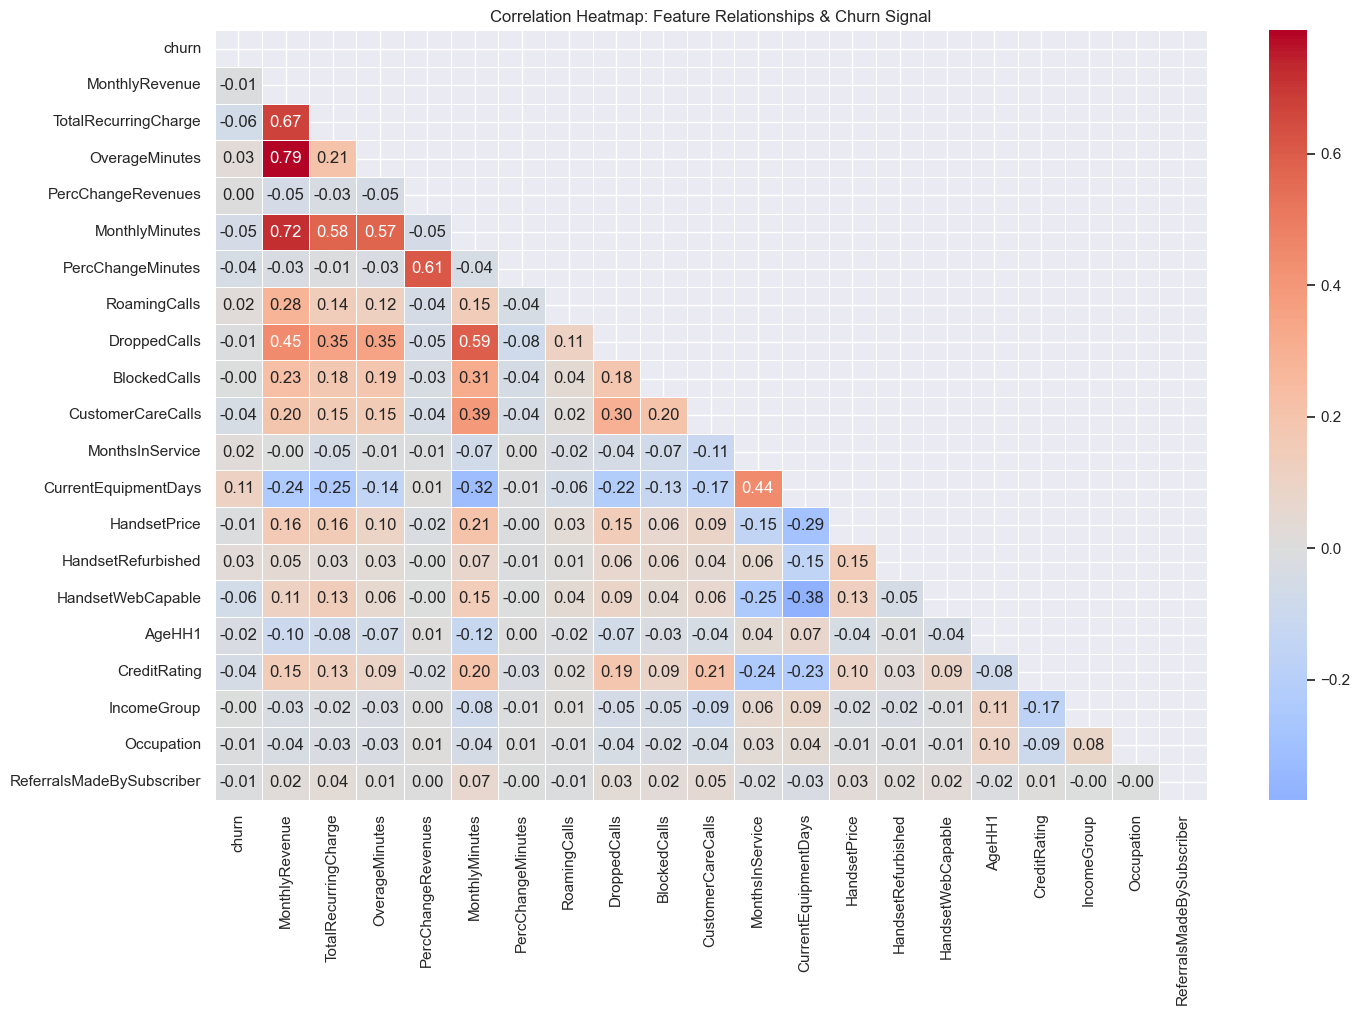

In [189]:


# 1. Calculate the correlation matrix
# We only care about how features relate to each other and Churn
matrix = train_df.corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(16, 10))

# 3. Draw the heatmap
# 'mask' is a pro-move: it hides the top half of the matrix since it's a mirror image

mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, 
            mask=mask, 
            annot=True,          # Set to False if it's too crowded
            fmt=".2f",           # Limit to 2 decimal places
            cmap='coolwarm',     # Red for positive, Blue for negative
            center=0, 
            linewidths=.5)

plt.title('Correlation Heatmap: Feature Relationships & Churn Signal')
plt.show()

**Step 5: Scaling the data**

In [190]:
from sklearn.preprocessing import StandardScaler, RobustScaler

In [191]:
# 1. Define your lanes (based on your Delta check)
extreme_features = ['MonthlyRevenue', 'OverageMinutes', 'PercChangeRevenues', 
               'MonthlyMinutes', 'PercChangeMinutes', 'RoamingCalls', "CurrentEquipmentDays"]

# All other numerical columns that weren't in the 'Extreme' list
stable_features = ['AgeHH1', 'IncomeGroup', 'MonthsInService', 'HandsetPrice', 
                   'DroppedCalls', 'BlockedCalls', 'CustomerCareCalls', "TotalRecurringCharge", "ReferralsMadeBySubscriber"]

# 2. Apply RobustScaler to the 'Extreme' lane (after capping)
robust_scaler = RobustScaler()
train_df[extreme_features] = robust_scaler.fit_transform(train_df[extreme_features])

# 3. Apply StandardScaler to the 'Stable' lane
standard_scaler = StandardScaler()
train_df[stable_features] = standard_scaler.fit_transform(train_df[stable_features])

In [192]:
train_df[extreme_features + stable_features].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
MonthlyRevenue,40837.0,0.26,1.04,-1.03,-0.40,0.00,0.60,4.83
OverageMinutes,40837.0,0.87,1.88,-0.08,-0.08,0.00,0.92,10.77
PercChangeRevenues,40837.0,-0.13,3.42,-12.42,-0.78,0.00,0.22,13.82
MonthlyMinutes,40837.0,0.27,0.88,-0.65,-0.37,0.00,0.63,3.70
PercChangeMinutes,40837.0,-0.04,1.52,-5.75,-0.52,0.00,0.48,5.11
RoamingCalls,40837.0,4.50,14.97,0.00,0.00,0.00,1.00,107.32
CurrentEquipmentDays,40837.0,0.16,0.79,-1.04,-0.40,0.00,0.60,2.61
AgeHH1,40837.0,0.00,1.00,-2.39,-0.48,-0.09,0.48,5.36
IncomeGroup,40837.0,0.00,1.00,-2.56,-0.44,0.09,0.62,1.68
MonthsInService,40837.0,-0.00,1.00,-1.30,-0.79,-0.28,0.53,4.29


In [193]:
train_df['churn'].value_counts(normalize=True)

churn
0.0    0.711805
1.0    0.288195
Name: proportion, dtype: float64

In [194]:
df['CreditRating'].unique()

array([1., 2., 3., 6., 0., 4., 5.])

In [195]:
train_df[["MonthlyRevenue", "TotalRecurringCharge", "OverageMinutes", "PercChangeRevenues", "RoamingCalls", "MonthlyMinutes", "CurrentEquipmentDays"]].groupby(train_df["churn"]).mean()

,MonthlyRevenue,TotalRecurringCharge,OverageMinutes,PercChangeRevenues,RoamingCalls,MonthlyMinutes,CurrentEquipmentDays
churn,,,,,,,
0.0,0.266336,0.039488,0.834264,-0.137398,4.316274,0.298119,0.105392
1.0,0.239667,-0.097530,0.943872,-0.112547,4.963074,0.199410,0.294250
